In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  

In [9]:
file = "data/elektrik_veri_hashed.xlsx"

df_hamamozu = pd.read_excel(file, sheet_name="Tahakkuk")
df_gumushacikoy = pd.read_excel(file, sheet_name="Tahakkuk 1")
df_goynucek = pd.read_excel(file, sheet_name="Tahakkuk 2")

In [10]:
df_all = pd.concat([df_hamamozu, df_gumushacikoy, df_goynucek])

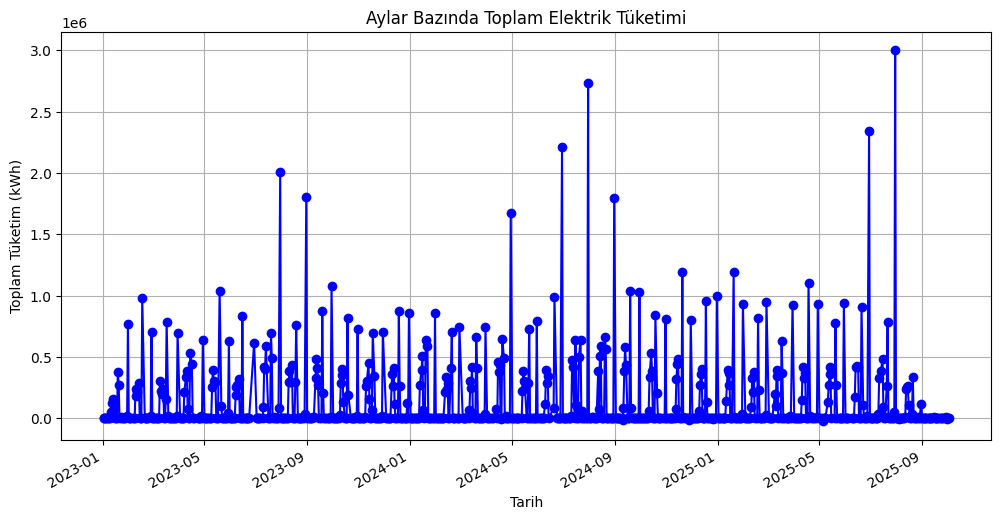

In [11]:
df_all['fatura_tarihi'] = pd.to_datetime(df_all['fatura_tarihi'])

df_all = df_all.sort_values('fatura_tarihi')

plt.figure(figsize=(12,6))
df_all.groupby('fatura_tarihi')['kwh'].sum().plot(kind='line', color='blue', marker='o')
plt.title("Aylar Bazında Toplam Elektrik Tüketimi")
plt.xlabel("Tarih")
plt.ylabel("Toplam Tüketim (kWh)")
plt.grid(True)
plt.show()

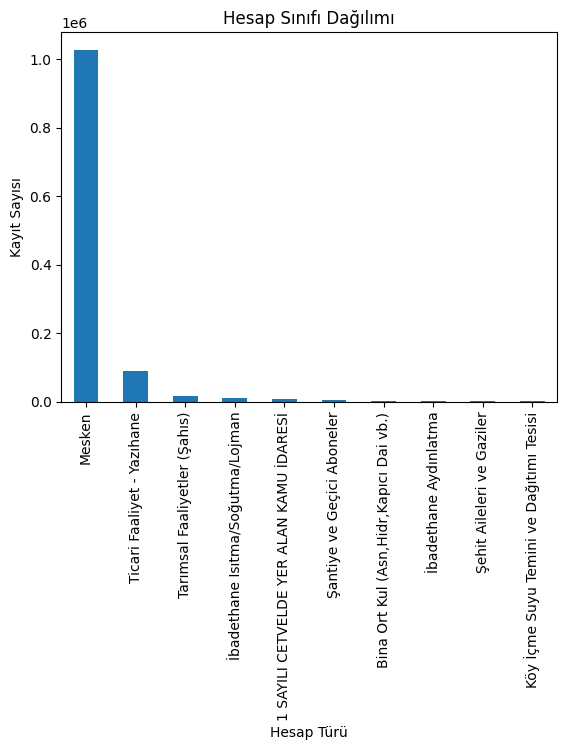

In [12]:
df_all["Hesap Sınıfı"].value_counts().head(10).plot(kind="bar")

plt.title("Hesap Sınıfı Dağılımı")
plt.xlabel("Hesap Türü")
plt.ylabel("Kayıt Sayısı")

plt.show()

c:\Users\musta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


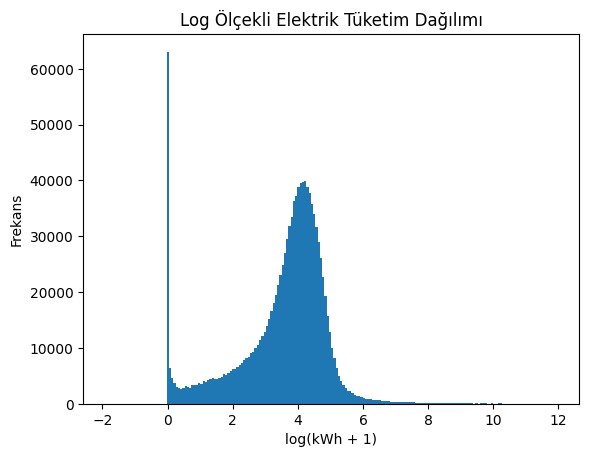

In [13]:
plt.hist(np.log1p(df_all["kwh"]), bins=200)

plt.title("Log Ölçekli Elektrik Tüketim Dağılımı")
plt.xlabel("log(kWh + 1)")
plt.ylabel("Frekans")

plt.show()

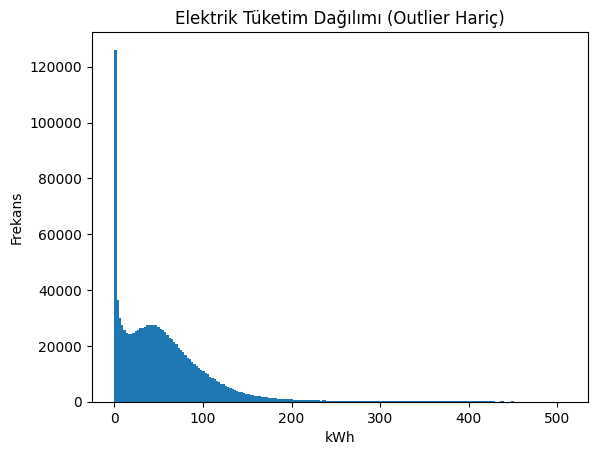

In [14]:
lower = df_all["kwh"].quantile(0.01)
upper = df_all["kwh"].quantile(0.99)

filtered = df_all[(df_all["kwh"] >= lower) & (df_all["kwh"] <= upper)]

plt.hist(filtered["kwh"], bins=200)

plt.title("Elektrik Tüketim Dağılımı (Outlier Hariç)")
plt.xlabel("kWh")
plt.ylabel("Frekans")

plt.show()

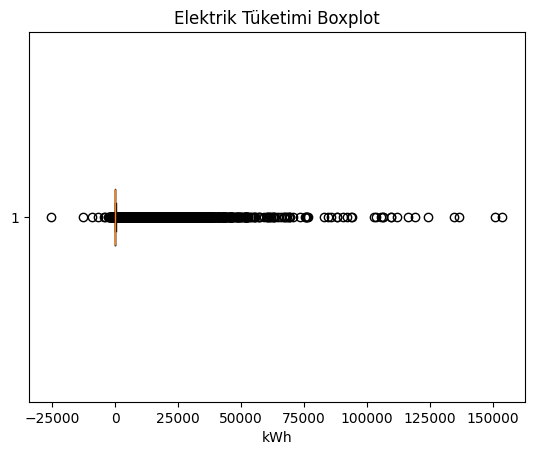

In [15]:
plt.boxplot(df_all["kwh"], vert=False)

plt.title("Elektrik Tüketimi Boxplot")
plt.xlabel("kWh")

plt.show()

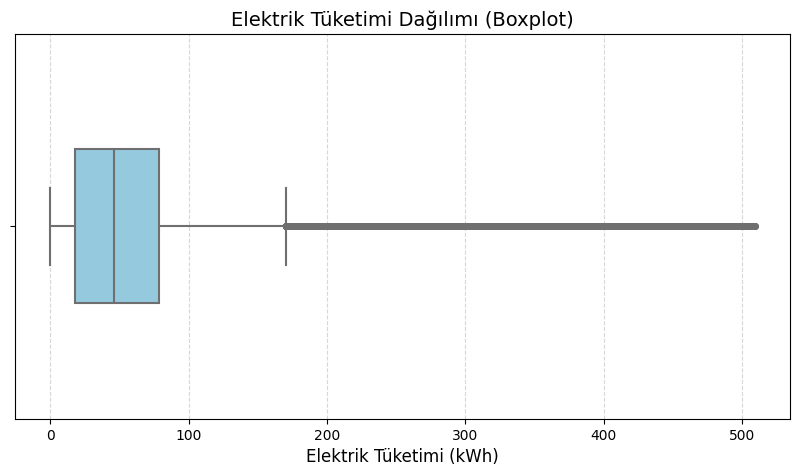

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=filtered["kwh"],
    color="skyblue",
    width=0.4,
    fliersize=4,
    linewidth=1.5
)

plt.title("Elektrik Tüketimi Dağılımı (Boxplot)", fontsize=14)
plt.xlabel("Elektrik Tüketimi (kWh)", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

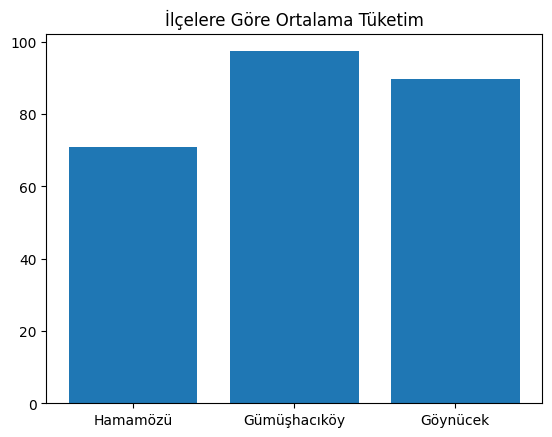

In [17]:
means = [
df_hamamozu["kwh"].mean(),
df_gumushacikoy["kwh"].mean(),
df_goynucek["kwh"].mean()
]

labels = ["Hamamözü","Gümüşhacıköy","Göynücek"]

plt.bar(labels,means)

plt.title("İlçelere Göre Ortalama Tüketim")

plt.show()

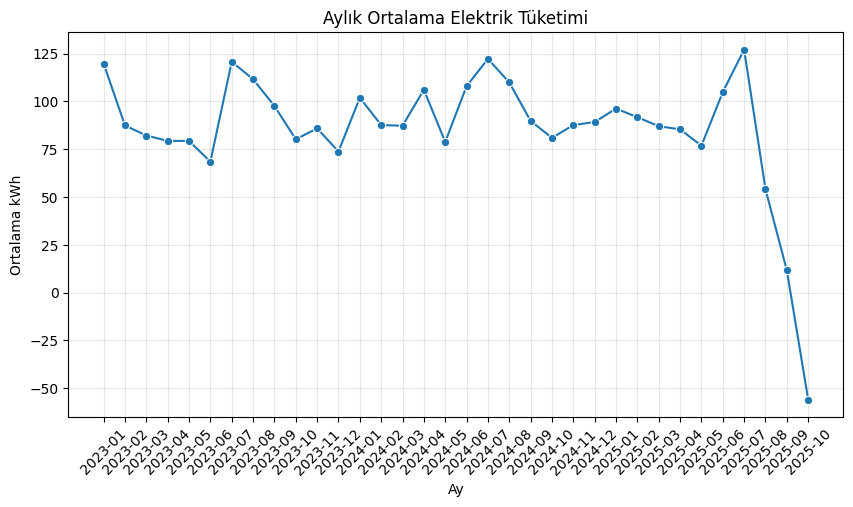

In [19]:
df_all['fatura_tarihi'] = pd.to_datetime(df_all['fatura_tarihi'])
monthly = df_all.groupby(df_all['fatura_tarihi'].dt.to_period("M"))['kwh'].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly.index.astype(str), y=monthly.values, marker="o")

plt.title("Aylık Ortalama Elektrik Tüketimi")
plt.xlabel("Ay")
plt.ylabel("Ortalama kWh")
plt.xticks(rotation=45) 
plt.grid(alpha=0.3)
plt.show()

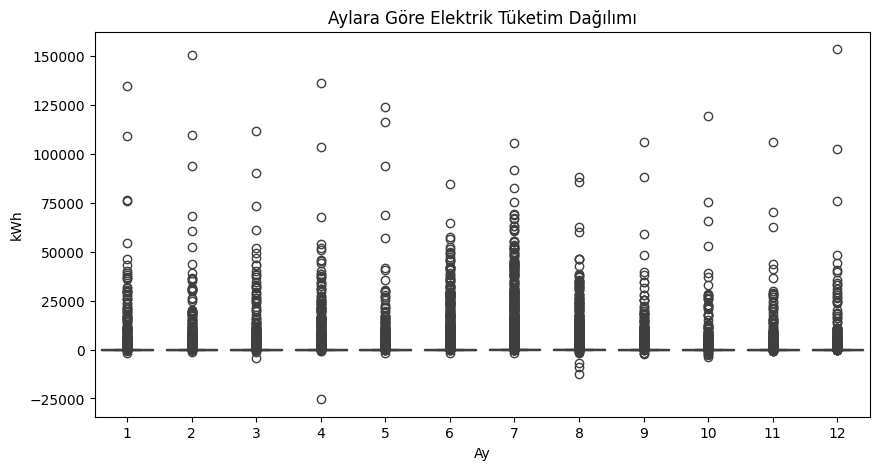

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df_all, x="ay", y="kwh")

plt.title("Aylara Göre Elektrik Tüketim Dağılımı")
plt.xlabel("Ay")
plt.ylabel("kWh")

plt.show()